# Algorithm K-Means

# Importation des bibliothéques

In [312]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import pickle
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

In [313]:
data = pd.read_csv('donnees_ecommerce.csv', encoding="ISO-8859-1")

In [314]:
data.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom


In [315]:
from analysis import description

In [316]:
description(data)

STATISTIQUES DESCRIPTIVES DU DATASET

Dimension du dataset: 541909 lignes x 8 colonnes

Lignes dupliquées: 5268 (0.97%)

Pourcentage de valeurs manquantes par colonne:
  CustomerID: 24.93%
  Description: 0.27%

Quantités négatives: 10624

Commandes annulées (InvoiceNo commençant par 'C'): 9288


{'dimension': (541909, 8),
 'pct_valeurs_manquantes': CustomerID     24.926694
 Description     0.268311
 StockCode       0.000000
 InvoiceNo       0.000000
 Quantity        0.000000
 InvoiceDate     0.000000
 UnitPrice       0.000000
 Country         0.000000
 dtype: float64,
 'lignes_dupliquees': np.int64(5268),
 'pct_lignes_dupliquees': np.float64(0.9721189350979592),
 'quantites_negatives': np.int64(10624),
 'commandes_annulees': np.int64(9288)}

## Data preprocessing

In [317]:
df = data.copy()

In [318]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df['Description'] = df['Description'].str.strip()
df.dropna(axis=0, subset=['InvoiceNo', 'Description'], inplace=True)
df = df[df['StockCode'].str[0].str.isdigit()]

In [319]:
# Calcul du montant total
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [320]:
df_clients = df.groupby('CustomerID').agg({
    'InvoiceNo': 'nunique',   # Fréquence
    'Quantity': 'sum',        # Volume
    'TotalPrice': 'sum'       # Valeur monétaire
})

df_clients.columns = ['Frequence', 'Quantite', 'Montant']

In [321]:
df_clients.describe()

,Frequence,Quantite,Montant
count,4335.000000,4335.000000,4335.000000
mean,4.245675,1192.902191,2021.007301
std,7.636337,5052.497735,8906.526607
min,1.000000,1.000000,0.000000
25%,1.000000,160.000000,305.410000
50%,2.000000,379.000000,668.110000
75%,5.000000,992.500000,1631.475000
max,206.000000,197420.000000,279138.020000


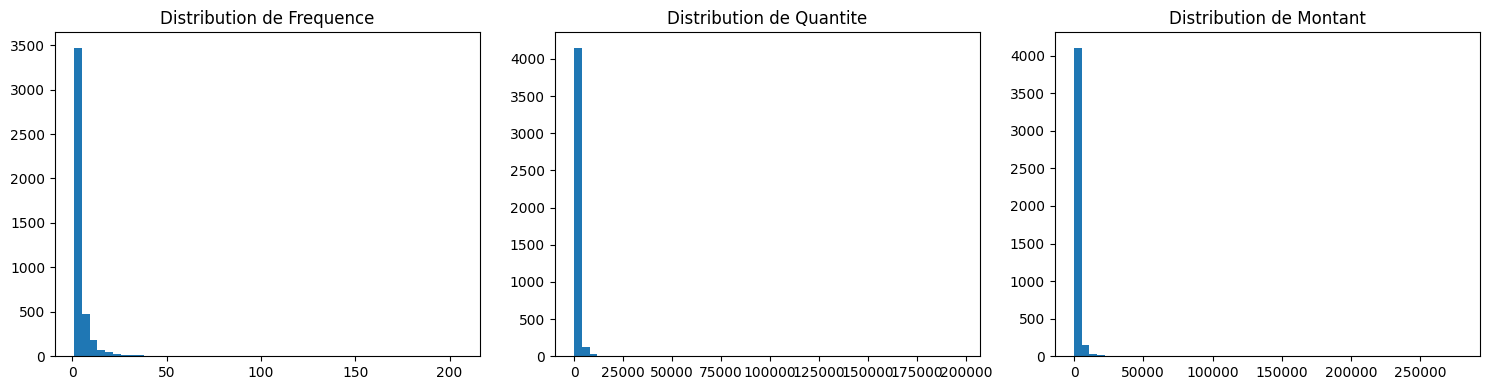

In [322]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

for ax, col in zip(axes, df_clients.columns):
    ax.hist(df_clients[col], bins=50)
    ax.set_title(f"Distribution de {col}")

plt.tight_layout()
plt.show()


**Standardisation**

In [323]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clients)

## Réalisation de l'ACP

In [324]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

**Variance expliquée cumulée**

In [325]:
# Variance expliquée cumulée
variance_cumulee = np.cumsum(pca.explained_variance_ratio_)

# Nombre minimal de composantes pour 95 %
n_components_95 = np.argmax(variance_cumulee >= 0.95) + 1

print(f"Nombre de composantes pour conserver 95% de la variance : {n_components_95}")

Nombre de composantes pour conserver 95% de la variance : 2


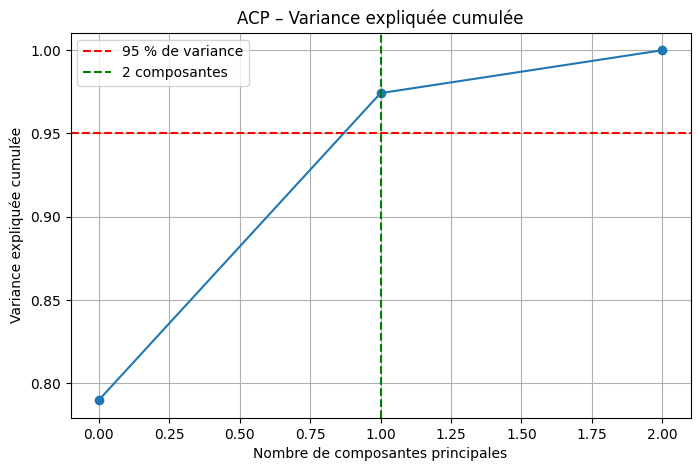

In [326]:
plt.figure(figsize=(8,5))
plt.plot(
    variance_cumulee,
    marker='o',
    linestyle='-'
)
plt.axhline(
    y=0.95,
    color='red',
    linestyle='--',
    label='95 % de variance'
)
plt.axvline(
    x=n_components_95 - 1,
    color='green',
    linestyle='--',
    label=f'{n_components_95} composantes'
)

plt.xlabel("Nombre de composantes principales")
plt.ylabel("Variance expliquée cumulée")
plt.title("ACP – Variance expliquée cumulée")
plt.legend()
plt.grid()
plt.show()


***La courbe de variance expliquée cumulée montre que 2 composantes principales suffisent pour expliquer 95 % de l’inertie totale.
Nous retenons donc 2 dimensions pour la suite de l’analyse, ce qui permet de réduire fortement la dimension tout en conservant l’essentiel de l’information.***

In [327]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

print("Variance expliquée par les 2 axes :", pca_2.explained_variance_ratio_)
df_pca_2 = pd.DataFrame(X_pca_2, columns=['PC1', 'PC2'])
df_pca_2.head()

Variance expliquée par les 2 axes : [0.78980875 0.18441468]


,PC1,PC2
0,13.851245,-8.356561
1,0.490487,0.135199
2,0.082476,-0.082003
3,-0.318138,-0.308155
4,-0.451043,-0.231910


## Choix du nombre optimal de clusters (K)

In [328]:
silhouette_scores = []

K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    silhouette_scores.append(score)


# Conversion en array (pratique)
silhouette_scores = np.array(silhouette_scores)

# Meilleur K
best_k = K_range[np.argmax(silhouette_scores)]
best_score = np.max(silhouette_scores)

print(f"✅ Meilleur nombre de clusters (K) : {best_k}")
print(f"📈 Score de silhouette maximal     : {best_score:.3f}")

✅ Meilleur nombre de clusters (K) : 2
📈 Score de silhouette maximal     : 0.961


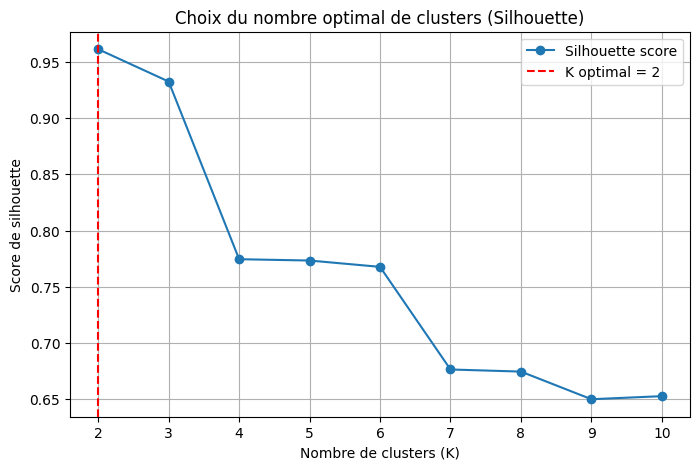

In [329]:
plt.figure(figsize=(8,5))
plt.plot(K_range, silhouette_scores, marker='o', label="Silhouette score")

plt.axvline(
    x=best_k,
    color='red',
    linestyle='--',
    label=f"K optimal = {best_k}"
)

plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Score de silhouette")
plt.title("Choix du nombre optimal de clusters (Silhouette)")
plt.legend()
plt.grid()
plt.show()

## L'algorithlme KMeans 

In [343]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df_clients['Cluster'] = clusters + 1
df_clients.head()

,Frequence,Quantite,Montant,Cluster
CustomerID,,,,
12346.0,1,74215,77183.60,2
12347.0,7,2458,4310.00,1
12348.0,4,2332,1437.24,1
12349.0,1,630,1457.55,1
12350.0,1,196,294.40,1


In [344]:
df_clients.columns

Index(['Frequence', 'Quantite', 'Montant', 'Cluster'], dtype='object')

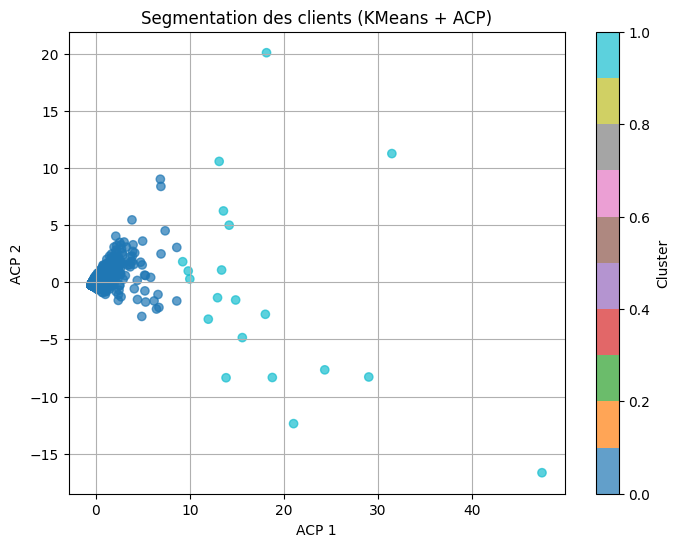

In [345]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    X_pca_2[:,0],
    X_pca_2[:,1],
    c=clusters,
    cmap='tab10',
    alpha=0.7
)
plt.xlabel("ACP 1")
plt.ylabel("ACP 2")
plt.title("Segmentation des clients (KMeans + ACP)")
plt.colorbar(scatter, label="Cluster")
plt.grid()
plt.show()


In [346]:
cluster_profile = df_clients.groupby('Cluster').mean()
cluster_size = df_clients['Cluster'].value_counts().sort_index()
cluster_profile['Effectif'] = cluster_size
cluster_profile

,Frequence,Quantite,Montant,Effectif
Cluster,,,,
1,3.957126,922.582619,1556.709576,4315
2,66.500000,59514.350000,102193.241500,20


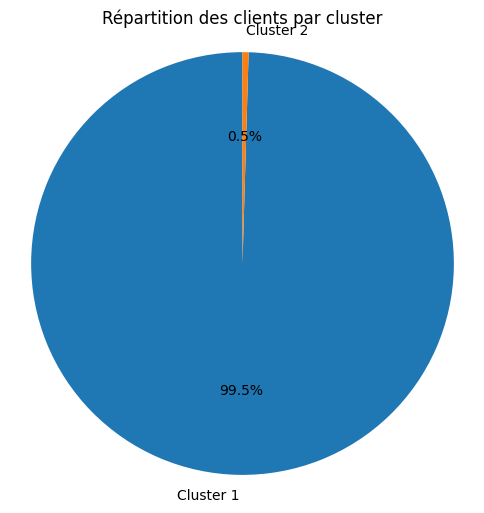

In [347]:
plt.figure(figsize=(6,6))

plt.pie(
    cluster_profile['Effectif'],
    labels=[f'Cluster {i}' for i in cluster_profile.index],
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Répartition des clients par cluster")
plt.axis('equal')  # cercle parfait
plt.show()


***On observe une répartition déséquilibrée, ce qui est typique des données e-commerce, avec un segment majoritaire et un segments plus spécifique correspondant à des clients à forte valeur ou à comportement atypique.***

***Nous avons segmenté les clients à partir de variables comportementales agrégées.
L’ACP a permis de comprendre la structure des données et de visualiser les clusters, tandis que le choix du nombre de groupes a été réalisé à l’aide du score de silhouette.
Les clusters obtenus sont interprétables et exploitables d’un point de vue business.***

**TRANSFORMATION SUPPLEMENTAIRE**

In [348]:
"""df_clients_log = df_clients.copy()
df_clients_log[['Frequence','Quantite','Montant']] = np.log1p(
    df_clients_log[['Frequence','Quantite','Montant']]
)"""

"df_clients_log = df_clients.copy()\ndf_clients_log[['Frequence','Quantite','Montant']] = np.log1p(\n    df_clients_log[['Frequence','Quantite','Montant']]\n)"

In [349]:
"""scaler = StandardScaler()
X_scaled_log = scaler.fit_transform(df_clients_log)"""

'scaler = StandardScaler()\nX_scaled_log = scaler.fit_transform(df_clients_log)'

**Réduire l’impact des très gros clients**

In [350]:
"""pca = PCA(n_components=2)
X_pca_2_log = pca.fit_transform(X_scaled_log)"""

'pca = PCA(n_components=2)\nX_pca_2_log = pca.fit_transform(X_scaled_log)'

In [351]:
"""kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled_log)

plt.figure(figsize=(8,6))
plt.scatter(
    X_pca_2_log[:,0],
    X_pca_2_log[:,1],
    c=clusters,
    cmap='tab10',
    alpha=0.7
)
plt.xlabel("ACP 1")
plt.ylabel("ACP 2")
plt.title("Segmentation clients après log + KMeans")
plt.grid()
plt.show()"""

'kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)\nclusters = kmeans.fit_predict(X_scaled_log)\n\nplt.figure(figsize=(8,6))\nplt.scatter(\n    X_pca_2_log[:,0],\n    X_pca_2_log[:,1],\n    c=clusters,\n    cmap=\'tab10\',\n    alpha=0.7\n)\nplt.xlabel("ACP 1")\nplt.ylabel("ACP 2")\nplt.title("Segmentation clients après log + KMeans")\nplt.grid()\nplt.show()'

La segmentation révèle une forte concentration des clients dans un segment majoritaire, ce qui est cohérent avec la distribution très asymétrique des comportements d’achat.
Ce déséquilibre n’est pas une erreur mais une caractéristique intrinsèque des données. Des transformations logarithmiques et une segmentation hiérarchique ont été explorées afin d’obtenir des groupes plus interprétables.

***Bien que le modèle à deux clusters présente de meilleures performances métriques, le modèle basé sur une transformation logarithmique et trois segments a été retenu pour le déploiement, car il offre une segmentation plus équilibrée et directement exploitable d’un point de vue opérationnel.***

**Sauvegarde du modèle**

In [352]:
# Sauvegarde du modèle KMeans
with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

In [353]:
# Sauvegarde du Scaler 
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

In [354]:
# Sauvegarde de l'objet ACP
with open('pca_model.pkl', 'wb') as f:
    pickle.dump(pca, f)

In [355]:
metrics_kmeans = {
    'variance_cumulee': variance_cumulee.tolist(),
    'n_components_95': int(n_components_95),
    'silhouette_scores': silhouette_scores,
    'K_range': list(K_range),
    'best_k': int(best_k)
}
with open('metrics_kmeans.pkl', 'wb') as f:
    pickle.dump(metrics_kmeans, f)